In [28]:
## Project Workflow
# Install libraries
!pip install pandas numpy matplotlib seaborn scikit-learn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

In [6]:
1. Data Loading
uploaded = files.upload()

Saving googleplaystore.csv.zip to googleplaystore.csv.zip


In [7]:
for file in os.listdir():
    if file.endswith(".zip"):
        with zipfile.ZipFile(file, 'r') as zip_ref:
            zip_ref.extractall()

In [8]:
df = pd.read_csv("googleplaystore.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


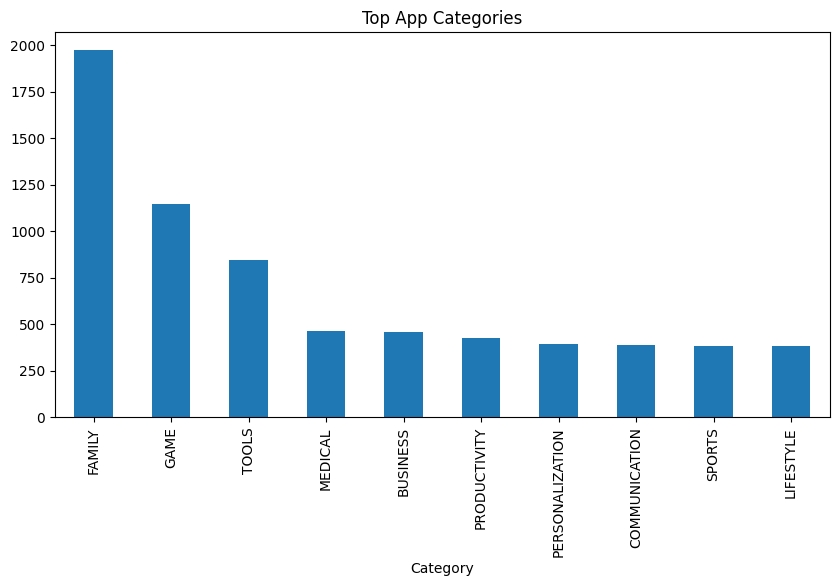

In [10]:
plt.figure(figsize=(10,5))
df['Category'].value_counts().head(10).plot(kind='bar')
plt.title("Top App Categories")
plt.show()

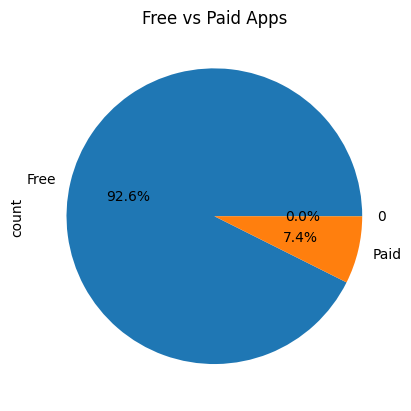

In [11]:
df['Type'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Free vs Paid Apps")
plt.show()

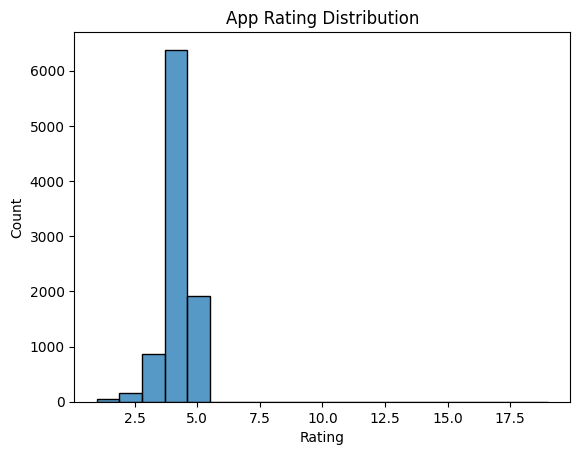

In [12]:
sns.histplot(df['Rating'], bins=20)
plt.title("App Rating Distribution")
plt.show()

In [13]:
df = df.dropna()

df['Installs'] = df['Installs'].str.replace('+','')
df['Installs'] = df['Installs'].str.replace(',','')
df['Installs'] = df['Installs'].astype(int)

df['Price'] = df['Price'].str.replace('$','')
df['Price'] = df['Price'].astype(float)

In [14]:
df['Success'] = np.where(df['Installs'] > 1000000,1,0)

In [15]:
le = LabelEncoder()

df['Category_Encoded'] = le.fit_transform(df['Category'])
df['Type_Encoded'] = le.fit_transform(df['Type'])

In [16]:
features = ['Rating','Reviews','Price','Category_Encoded','Type_Encoded']

In [17]:
scaler = StandardScaler()

cluster_data = scaler.fit_transform(df[['Rating','Reviews','Price']])

kmeans = KMeans(n_clusters=3, random_state=42)

df['App_Cluster'] = kmeans.fit_predict(cluster_data)

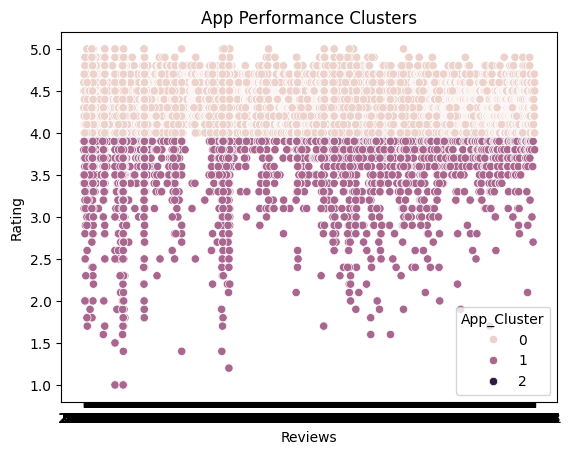

In [18]:
sns.scatterplot(x=df['Reviews'], y=df['Rating'], hue=df['App_Cluster'])
plt.title("App Performance Clusters")
plt.show()

In [19]:
X = df[['Rating','Reviews','Price','Category_Encoded','Type_Encoded','App_Cluster']]
y = df['Success']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [20]:
pred = rf.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      1315
           1       0.91      0.86      0.89       557

    accuracy                           0.93      1872
   macro avg       0.93      0.91      0.92      1872
weighted avg       0.93      0.93      0.93      1872



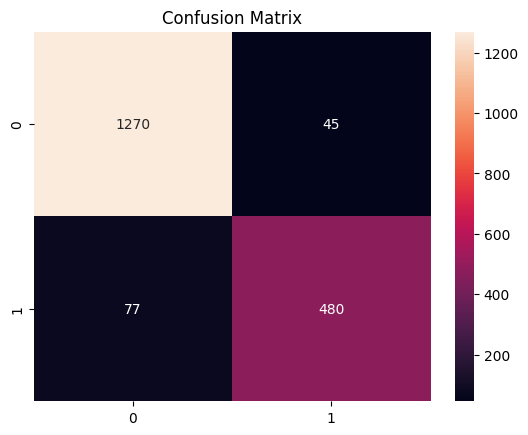

In [21]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

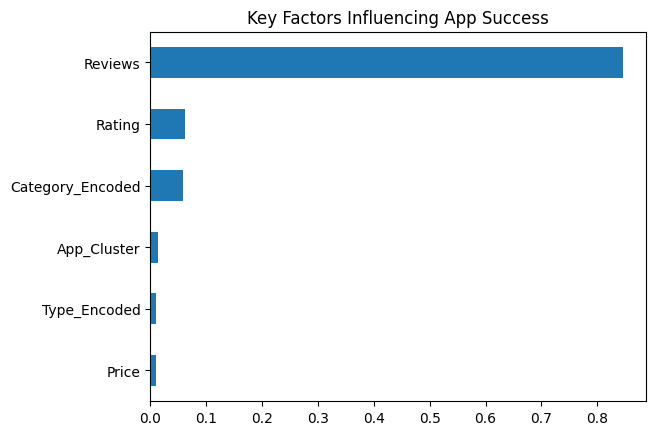

In [22]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh')

plt.title("Key Factors Influencing App Success")
plt.show()

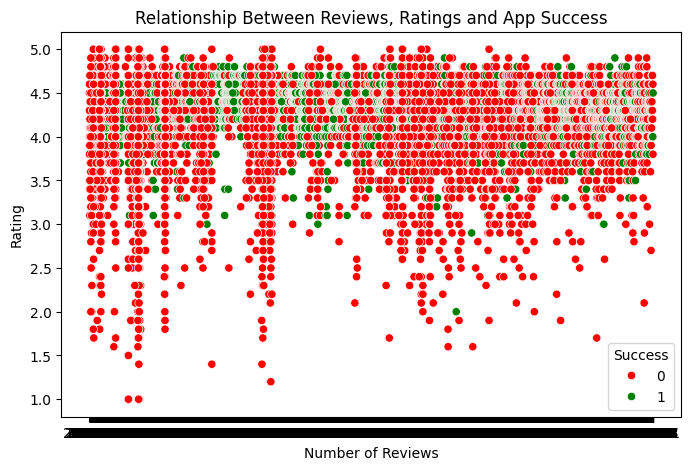

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Reviews'],
    y=df['Rating'],
    hue=df['Success'],
    palette=['red','green']
)

plt.title("Relationship Between Reviews, Ratings and App Success")

plt.xlabel("Number of Reviews")

plt.ylabel("Rating")

plt.show()

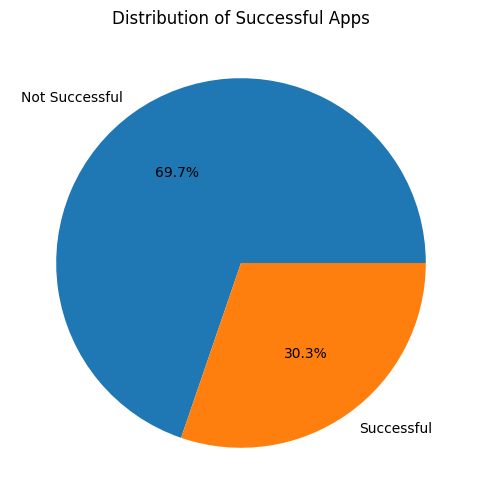

In [24]:
success_counts = df['Success'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    success_counts,
    labels=['Not Successful','Successful'],
    autopct='%1.1f%%'
)

plt.title("Distribution of Successful Apps")

plt.show()

In [25]:
new_app = pd.DataFrame({
    'Rating':[4.5],
    'Reviews':[50000],
    'Price':[0],
    'Category_Encoded':[3],
    'Type_Encoded':[0],
    'App_Cluster':[1]
})

prediction = rf.predict(new_app)

print("Predicted Success:", prediction)

Predicted Success: [1]


In [26]:
if prediction[0] == 1:
    print("The app has high probability of success in the market.")
else:
    print("The app may struggle to gain popularity.")

The app has high probability of success in the market.


In [27]:
print("FINAL PROJECT CONCLUSION")
print("--------------------------------")

print("""
This project demonstrates that machine learning can be used to
predict the success of mobile applications based on factors such
as ratings, reviews, pricing, and category.

The hybrid machine learning approach combining clustering and
classification improves the understanding of app performance
patterns.

Among the tested methods, Random Forest provided the most reliable
predictions due to its ability to capture complex relationships
between app features and install behavior.

The analysis shows that higher ratings and larger numbers of
reviews significantly increase the likelihood of app success.
""")

FINAL PROJECT CONCLUSION
--------------------------------

This project demonstrates that machine learning can be used to
predict the success of mobile applications based on factors such
as ratings, reviews, pricing, and category.

The hybrid machine learning approach combining clustering and
classification improves the understanding of app performance
patterns.

Among the tested methods, Random Forest provided the most reliable
predictions due to its ability to capture complex relationships
between app features and install behavior.

The analysis shows that higher ratings and larger numbers of
reviews significantly increase the likelihood of app success.

